In [1]:
import h5py
import torch
from math import factorial, sqrt, comb, ceil
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from definitions import (
    orientation_score_transform,
    cost_function,
    modulo,
    adaptive_sigmoid_norm)
from PIL import Image
import torchvision.transforms as T
from torchvision.transforms import v2
from torch.utils.data import TensorDataset, DataLoader
from functools import lru_cache
import random
import numpy as np
from tqdm import tqdm

torch.cuda.is_available()

shft = 0


# Definitions

Set Seed

In [2]:
def set_seed(seed: int = 42):
    # Python RNG
    random.seed(seed)

    # NumPy RNG
    np.random.seed(seed)

    # PyTorch RNG (CPU)
    torch.manual_seed(seed)

    # PyTorch RNG (all GPUs)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # For PyTorch 2.x compilers
    #torch.use_deterministic_algorithms(True)

definitions derivation ground truth

In [3]:
def perfect_lift(points, No): 
    # points have shape x,y. We want y,x 
    points_e = torch.cat((points[:,[1,0]], points[:,[1,0]][0, None]), dim=0)
    v = points_e[:-1] - points_e[1:]
    orientation = modulo(torch.round(torch.arctan2(v[:, 0], v[:, 1]) * No / (2 * torch.pi)), No)
    
    return torch.cat((orientation[:, None], points_e[:-1:]), dim=1)

In [4]:
def make_image_lift(perfectlift, No, f):
    lift = torch.ones(No, f.shape[1], f.shape[0])
    lift[perfectlift[:, 0].to(torch.int64), perfectlift[:, 1].to(torch.int64), perfectlift[:, 2].to(torch.int64)] = 0
    lift[modulo(perfectlift[:, 0]+ No/2, No).to(torch.int64), perfectlift[:, 1].to(torch.int64), perfectlift[:, 2].to(torch.int64)] = 0
    return lift

In [5]:
def clip_gt(list, f):
    gt_clipped = []
    for c in list:
        clipped = torch.round(c) + torch.tensor([0, f.shape[1]/2, f.shape[0]/2])
        in_image = (clipped[:, 1] >= 0) * (clipped[:, 2] >= 0) * (clipped[:, 1] < f.shape[1]) * (clipped[:, 2] < f.shape[0])
        clipped = clipped[in_image]
        same_as_next = torch.all(clipped[1:, 1:] == clipped[:-1, 1:], dim=-1)
        mask = torch.cat([~same_as_next, torch.tensor([True])]) #~ makes true to false and false to true, torch.cat add an extra true to keep the correct length of the mask
        clipped = clipped[mask]
        gt_clipped.append(clipped)

    return gt_clipped

# Import SEM image

In [6]:
data_folder = r"C:/Users/levis/OneDrive - ASML/Documents/2602_dEPE2_AlexDuarte/depe_sim_02"

set_seed(100)

# Split Data
imgs = list(Path(data_folder).iterdir())
imgs.sort()

In [7]:
hvsem_file="stack_hvsem.tiff"
hvsems = []

for idx in range(len(imgs)):
    hvsems.append(v2.functional.pil_to_tensor(
    Image.open(Path.joinpath(imgs[idx], hvsem_file))
    ))

lines_sem_file="lines_sem.tiff"
lines_sems = []

for idx in range(len(imgs)):
    lines_sems.append(v2.functional.pil_to_tensor(
    Image.open(Path.joinpath(imgs[idx], lines_sem_file))
    ))

holes_sem_file="holes_sem.tiff"
holes_sems = []

for idx in range(len(imgs)):
    holes_sems.append(v2.functional.pil_to_tensor(
    Image.open(Path.joinpath(imgs[idx], holes_sem_file))
    ))

Lines + Pillars

In [8]:
fs = (torch.cat(lines_sems, dim=0) + torch.cat(holes_sems, dim=0)).to("cuda") #torch.cat(hvsems, dim=0).to("cuda")
fs.shape
fs.device

device(type='cuda', index=0)

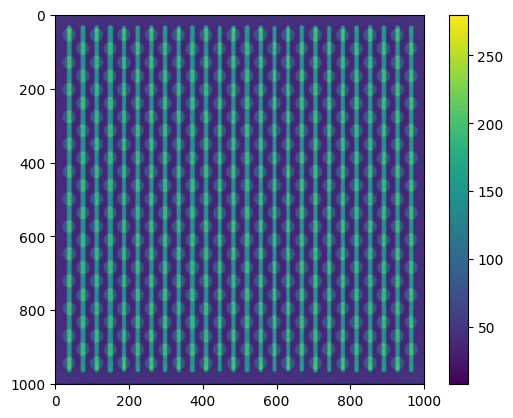

In [9]:
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(fs[0].cpu())
fig.colorbar(cbar, ax=ax)

### Shift Pillars

In [10]:
fs = (torch.cat(lines_sems, dim=0) + torch.roll(torch.cat(holes_sems, dim=0), shifts = shft, dims=-1)).to("cuda") #torch.cat(hvsems, dim=0).to("cuda")
fs.shape
fs.device

device(type='cuda', index=0)

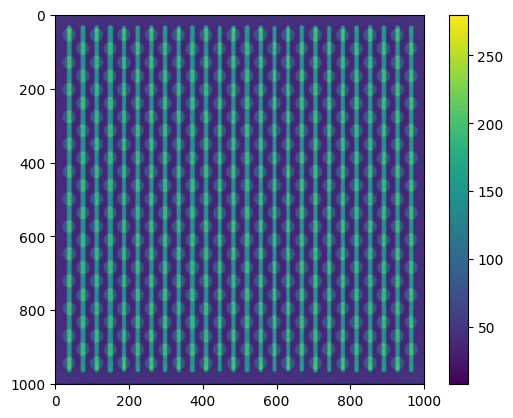

In [11]:
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(fs[0].cpu())
fig.colorbar(cbar, ax=ax)

## Ground truth segmentation of SEM image

### Import ground truth segmentation of SEM image

In [12]:
No = 12;

In [13]:
top_contours = []
bottom_contours = []

for idx in range(len(imgs)):
    top_contours.append(np.load(Path.joinpath(imgs[idx], "lines.npz")))
    bottom_contours.append(np.load(Path.joinpath(imgs[idx], "holes.npz")))



### Make perfect lift

In [14]:
perfectlifts_top = [
    [perfect_lift(torch.tensor(top_contours[i][t]), No) for t in top_contours[i].files] 
    for i in range(len(top_contours))
]

perfectlifts_top = [clip_gt(perfectlifts_top[i], fs[i]) for i in range(len(perfectlifts_top))]

perfectlifts_bottom = [
    [perfect_lift(torch.tensor(bottom_contours[i][t]), No) for t in bottom_contours[i].files] 
    for i in range(len(bottom_contours))
]

perfectlifts_bottom = [clip_gt(perfectlifts_bottom[i], fs[i]) for i in range(len(perfectlifts_bottom))]

In [15]:
perfectlifts = [torch.tensor(np.concatenate(t + b)) for t, b in zip(perfectlifts_top, perfectlifts_bottom)]

In [16]:
lifts = torch.stack(
    
            [make_image_lift(p, No, fs[0]) for p in perfectlifts] 
    
).to(fs.device)

lifts.shape

torch.Size([20, 12, 1001, 1001])

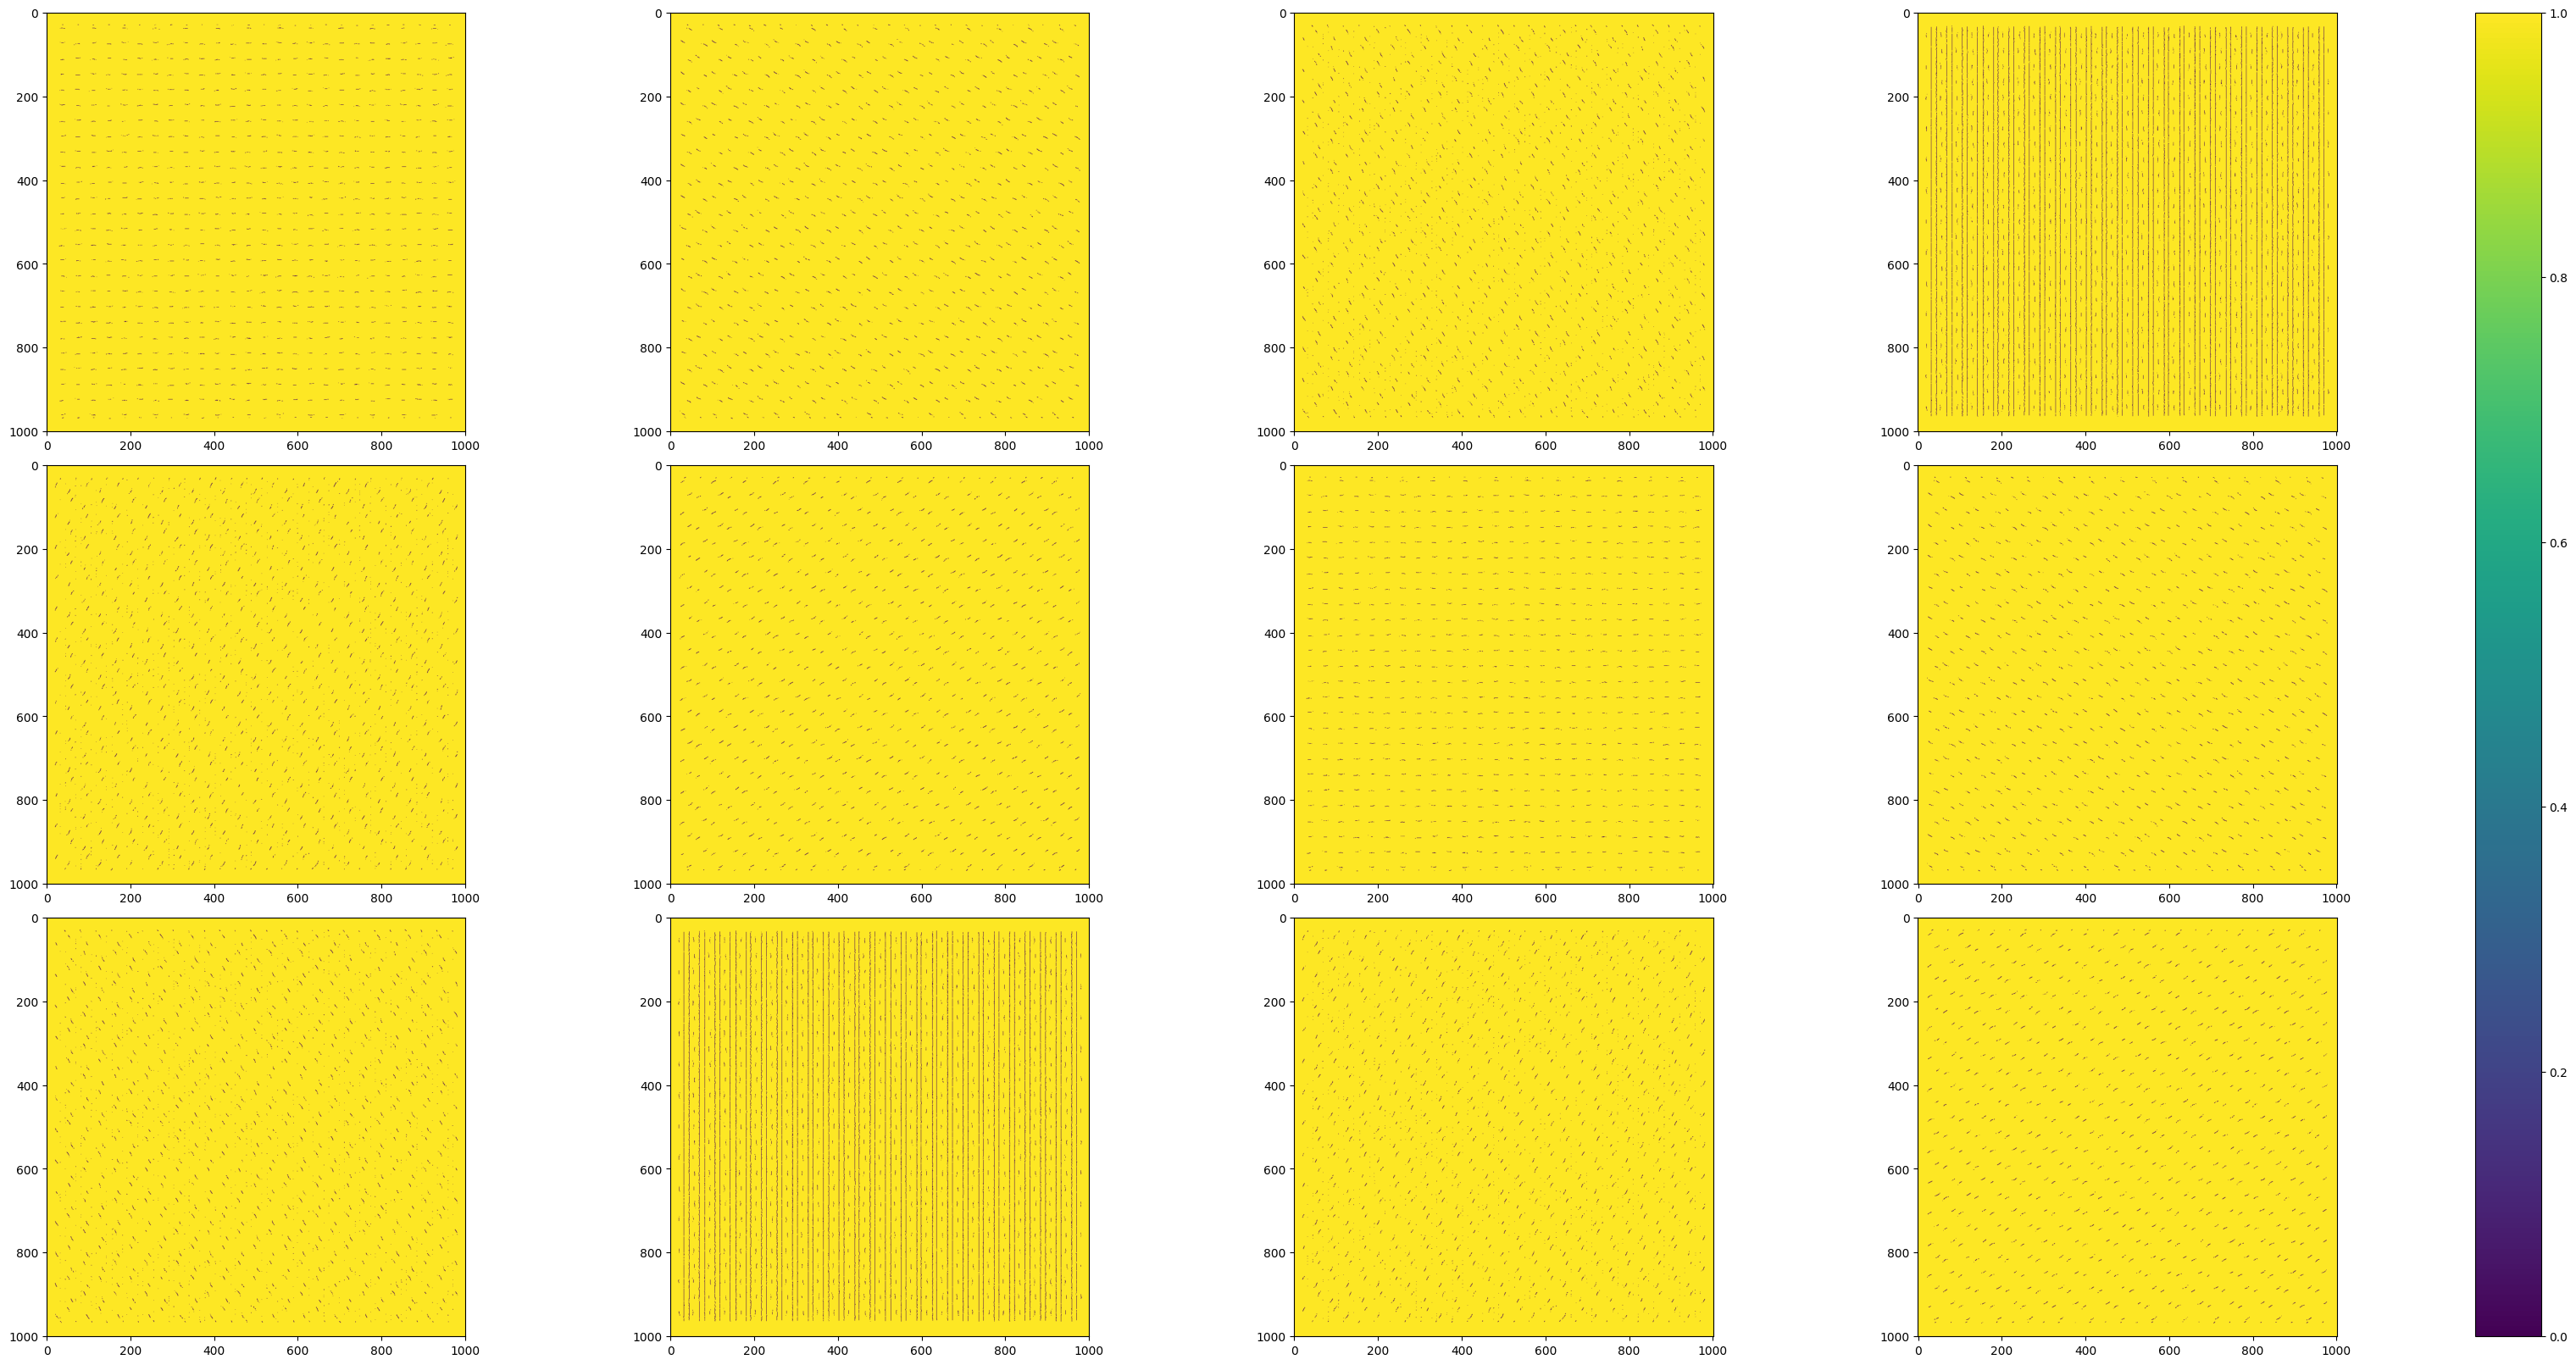

In [17]:
vmin = 0
vmax = 1

plot = lifts[0]

fig, ax = plt.subplots(ceil(plot .shape[0]/4), 4, figsize=(8 * 4, 4 * 4), layout="constrained")

ims = []
for i in range(ceil(plot.shape[0]/4)):
    for j in range(4):
        im = ax[i, j].imshow(plot [i * 4 + j, :, :].cpu(), vmin=vmin, vmax=vmax,
                        cmap="viridis",
                        aspect="equal")
        ims.append(im)

fig.colorbar(ims[0], ax=ax, location="right");

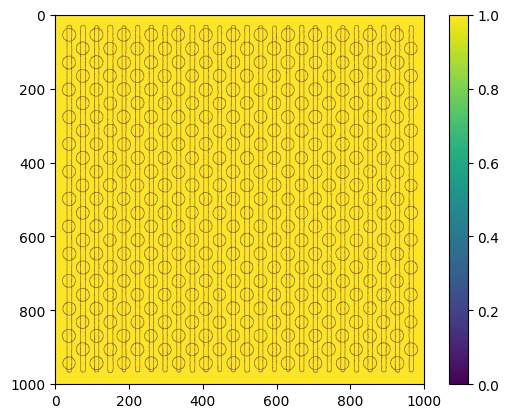

In [18]:

fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(torch.min(plot, dim=0)[0].cpu())
fig.colorbar(cbar, ax=ax)

## Reshape data set

In [19]:
# fs is a tensor of shape [N, 1, 1001, 1001] (N images, 1 channel --> grayscale)
# Step 1: Crop to 1000x1000, so that it is divisible by 200
fs_cropped = fs[:, :1000, :1000]
lifts_cropped = lifts[:, :1000, :1000]

# Step 2: Unfold 
fs_tiles = fs_cropped.unfold(-2, 200, 200).unfold(-2, 200, 200)
# the shape is now: [N, 5, 5, 200, 200]
lifts_tiles = lifts_cropped.unfold(-2, 200, 200).unfold(-2, 200, 200)
# De shape is now: [N, No, 5, 5, 200, 200]

# Step 3: Reorganise to [N*25, 200, 200]
fs_tiles = fs_tiles.contiguous().view(-1, 200, 200)
lifts_tiles = lifts_tiles.permute(0, 2, 3, 1, 4, 5).contiguous().view(-1, No, 200, 200)

print(f"Old shape: {fs.shape}")
print(f"New shape: {fs_tiles.shape}") # this will be [N*25, 200, 200] 

print(f"Old shape: {lifts.shape}")
print(f"New shape: {lifts_tiles.shape}") # this will be [N*25, No, 200, 200] 

Old shape: torch.Size([20, 1001, 1001])
New shape: torch.Size([500, 200, 200])
Old shape: torch.Size([20, 12, 1001, 1001])
New shape: torch.Size([500, 12, 200, 200])


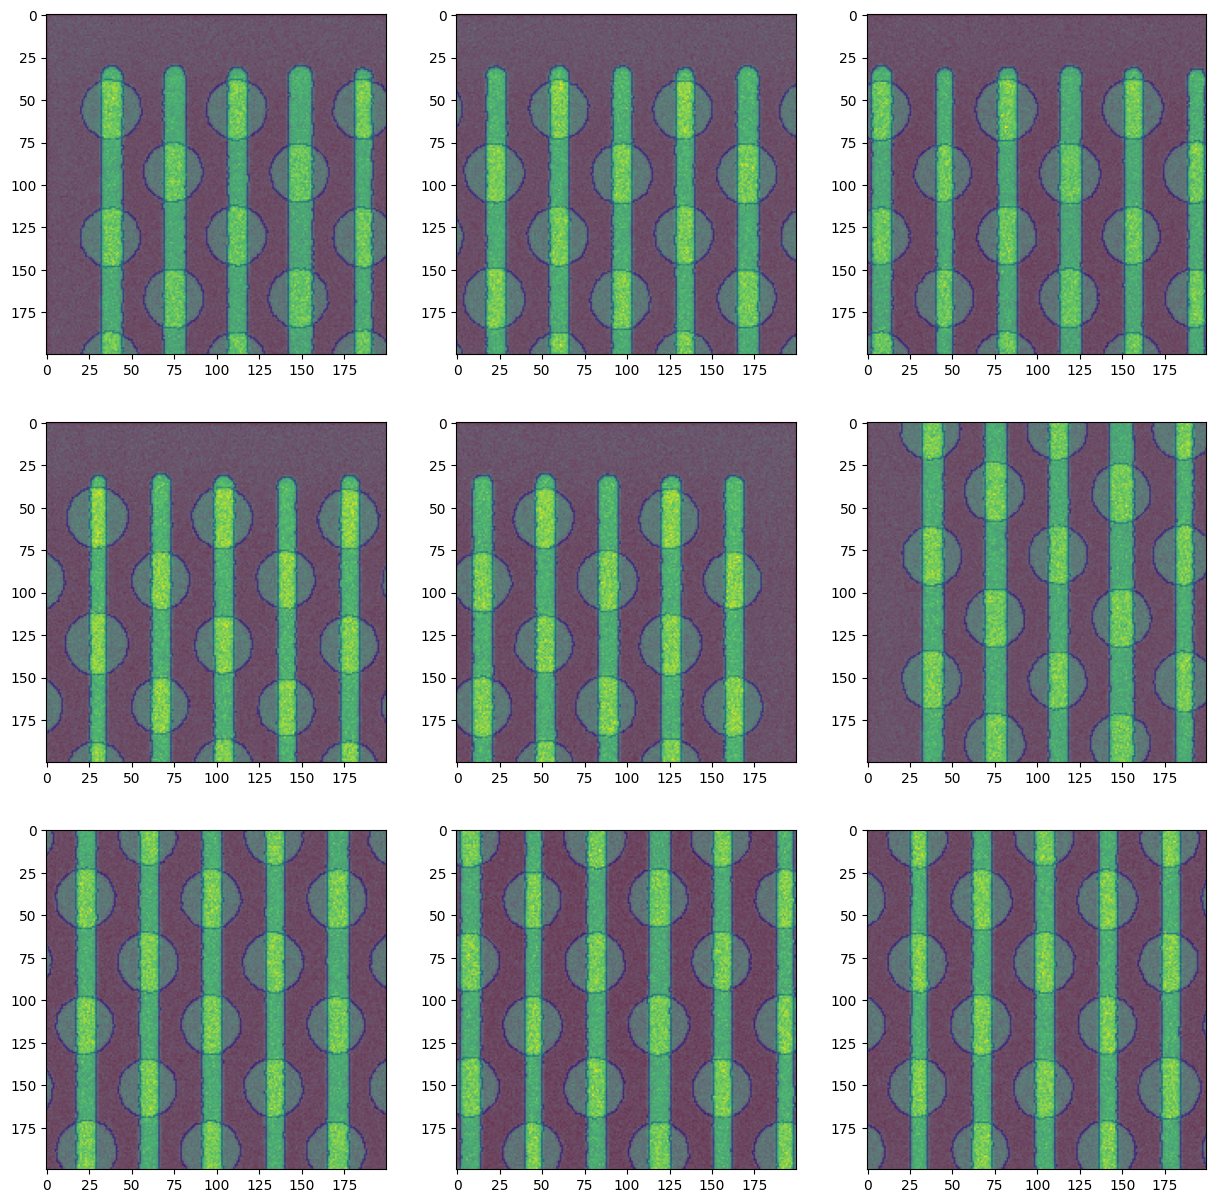

In [20]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for i, a in enumerate(ax.flatten()):
    a.imshow(fs_tiles[i].cpu())
    a.imshow(lifts_tiles[i].cpu().min(-3)[0], alpha=0.2)

## Import Experimental dataset

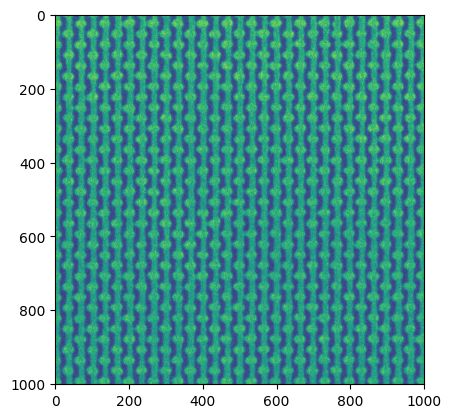

In [21]:
#D23_mod11_CPO1_nominal_uncorrected_image-36-1-0-11-0-Channel--2147483648-before.bmp without mistake _, with mistake _2
#D23_mod11_CPO1_offset1_uncorrected_image-37-1-0-11-0-Channel--2147483648-before.bmp _4
#D23_mod11_CPO1_offset2_uncorrected_image-38-1-0-11-0-Channel--2147483648-before.bmp _5
#D23_mod11_CPO1_offset3_uncorrected_image-39-1-0-11-0-Channel--2147483648-before.bmp _6
#D23_mod11_CPO1_maxoffset_uncorrected_image-40-1-0-11-0-Channel--2147483648-before.bmp _3

index = 6

test = v2.functional.pil_to_tensor(
    Image.open("C:/Users/levis/OneDrive - ASML/Documents/2025_Orion_MEM/D23_mod11_CPO1_offset3_uncorrected_image-39-1-0-11-0-Channel--2147483648-before.bmp")   
    ).to("cuda")

plt.imshow(test[:,200:1201,1000:2001][0].cpu())

# Learn parameters for identification of edge structures

## loss function
    

In [22]:
def dice_loss(input, target, smooth=1e-10):
    """
    Continuous DICE coefficient suitable for use as a loss function for binary segmentation, calculated as:
    $$
        1 - \\frac{2*(input*target).sum()+smooth}{input.sum()+target.sum()+smooth}
    $$

    Parameters
    ------------
    input: torch.Tensor
    Tensor of any shape with scalar elements in the range [0,1].

    target: torch.Tensor
    Label tensor with the same shape as the input with elements in the set {0,1}.

    smooth: float
    Smoothing factor that is added to both the numerator and denominator to avoid divide-by-zero.

    """
    AinterB = (input.view(-1) * target.view(-1)).sum()
    A = input.view(-1).sum()
    B = target.view(-1).sum()
    dice = (2 * AinterB + smooth) / (A + B + smooth)
    return 1 - dice


In [23]:
def tversky_loss(input, target, alpha, beta, eps=1e-6, gamma=1.33):
    TP = (input * target).sum(dim=(-3,-2,-1))
    FP = (input * (1 - target)).sum(dim=(-3,-2,-1))
    FN = ((1 - input) * target).sum(dim=(-3,-2,-1))

    denom = TP + alpha * FP + beta * FN + eps
   
    tversky_index = (TP + eps) / denom
    #loss = (1 - tversky_index)**(1/gamma)   
    #loss = -torch.log(tversky_index + eps)
    #loss = -torch.pow(torch.log(tversky_index + eps), 1/gamma)
    loss = (1 - tversky_index)

    return loss.mean()

## the model

In [24]:
def model(f, σs , σa, λ, p, t, scale):
    No = 12

    os = orientation_score_transform(f, No, 0.9)
    os_norm = adaptive_sigmoid_norm(os.real, scale)
    images = os_norm.sum(dim=-3) 
        
    # os = orientation_score_transform(images, No, 0.9)
    # os_norm = adaptive_sigmoid_norm(os.real, scale)
    # images = os_norm.sum(dim=-3)

    # os = orientation_score_transform(images, No, 0.9)
    # os_norm = adaptive_sigmoid_norm(os.real, scale)
    # images = os_norm.sum(dim=-3)

    os = orientation_score_transform(images, No, 0.9)    
    cost = cost_function(torch.abs(os.imag), σs, σa, λ, p)

    # eps controls sharpness
    eps = 1e-3    
    bin = torch.sigmoid((cost - t) / eps) #if cost is bigger than threshold t --> almost 1, if cost is samller than threshold t --> almost 0

    return bin

In [25]:
def model_nobin(f, σs , σa, λ, p, scale):
    No = 12

    os = orientation_score_transform(f, No, 0.9)
    os_norm = adaptive_sigmoid_norm(os.real, scale)
    images = os_norm.sum(dim=-3) 
        
    # os = orientation_score_transform(images, No, 0.9)
    # os_norm = adaptive_sigmoid_norm(os.real, scale)
    # images = os_norm.sum(dim=-3)

    # os = orientation_score_transform(images, No, 0.9)
    # os_norm = adaptive_sigmoid_norm(os.real, scale)
    # images = os_norm.sum(dim=-3)

    os = orientation_score_transform(images, No, 0.9)    
    cost = cost_function(torch.abs(os.imag), σs, σa, λ, p)
    return cost

In [26]:
log_σs = torch.tensor(0., device="cuda", requires_grad=True) 
log_σa = torch.tensor(0., device="cuda", requires_grad=True)
sqrt_λ_norm = torch.tensor(0.1, device="cuda", requires_grad=True)
sqrt_p = torch.tensor(0., device="cuda", requires_grad=True)
t = torch.tensor(0., device="cuda", requires_grad=True)
log_scale = torch.zeros(12, device="cuda", requires_grad=True)


parameters = [log_σs, log_σa, sqrt_λ_norm, sqrt_p , t , log_scale] 
optimizer = torch.optim.AdamW(parameters, lr=0.05)
# optimizer = torch.optim.SGD(parameters, lr=0.0001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

batch_size = 4
dataset = TensorDataset(fs_tiles[:17*25], lifts_tiles[:17*25])
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


losses = []

num_epochs = 10

for epoch in range(num_epochs):
    epoch_loss = 0
    
    for i, (batch_fs, batch_lifts) in enumerate(data_loader):
        optimizer.zero_grad() # set x.grad = 0 for all relevant tensors x  

        σs = torch.exp(log_σs) #.clamp(-10,10)
        σa = torch.exp(log_σa) 
        λ_norm = sqrt_λ_norm**2
        p = torch.log(1 + torch.exp(sqrt_p)) + 1 #torch.exp(log_p)
        scale = torch.exp(log_scale)            
        
        cost = model(batch_fs, σs , σa , 100. * λ_norm, p, torch.sigmoid(t), scale[None,:,None,None])  

        beta = 0.99 
        alpha = 1 - beta
        loss = tversky_loss(1. - cost, 1. - batch_lifts, alpha, beta)
                
        loss.backward()# x.grad += (pd loss)/(pd x) for all relevant tensors x

        names = ["log_σs", "log_σa", "λ_norm", "p", "t", "log_scale"] 
        
        # for name, p in zip(names, parameters):
        #     # if not torch.isfinite(p).all():
        #     print(i, name, p)
        #     print(i, "grad", name, p.grad)
                
        # if not torch.isfinite(loss).all():
        #print("loss", loss)

        #torch.nn.utils.clip_grad_norm_(parameters, max_norm=0.1)

        optimizer.step()
        epoch_loss += loss.item()
        
    scheduler.step()
    
    # average loss 
    avg_loss = epoch_loss / len(data_loader)
    losses.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}", end='\r')


fig, ax = plt.subplots(1, 1)
ax.plot(losses)
ax.loglog();


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(losses);


In [ ]:
torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1 , torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]

In [ ]:
# save_dict = {
#     "log_σs": log_σs.detach(),
#     "log_σa": log_σa.detach(),
#     "sqrt_λ_norm": sqrt_λ_norm.detach(),
#     "sqrt_p": sqrt_p.detach(),
#     "t": t.detach(),
#     "log_scale": log_scale.detach(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "scheduler_state_dict": scheduler.state_dict(),
#     "losses": losses,
# }

# torch.save(save_dict, "model_parameters_costfunction.pth")

In [27]:
saved_parameters = torch.load("model_parameters_costfunction.pth")
log_σs = saved_parameters["log_σs"]
log_σa = saved_parameters["log_σa"]
sqrt_λ_norm = saved_parameters["sqrt_λ_norm"]
sqrt_p = saved_parameters["sqrt_p"]
t = saved_parameters["t"]
log_scale = saved_parameters["log_scale"]

test with images from SYNTHETIC data set

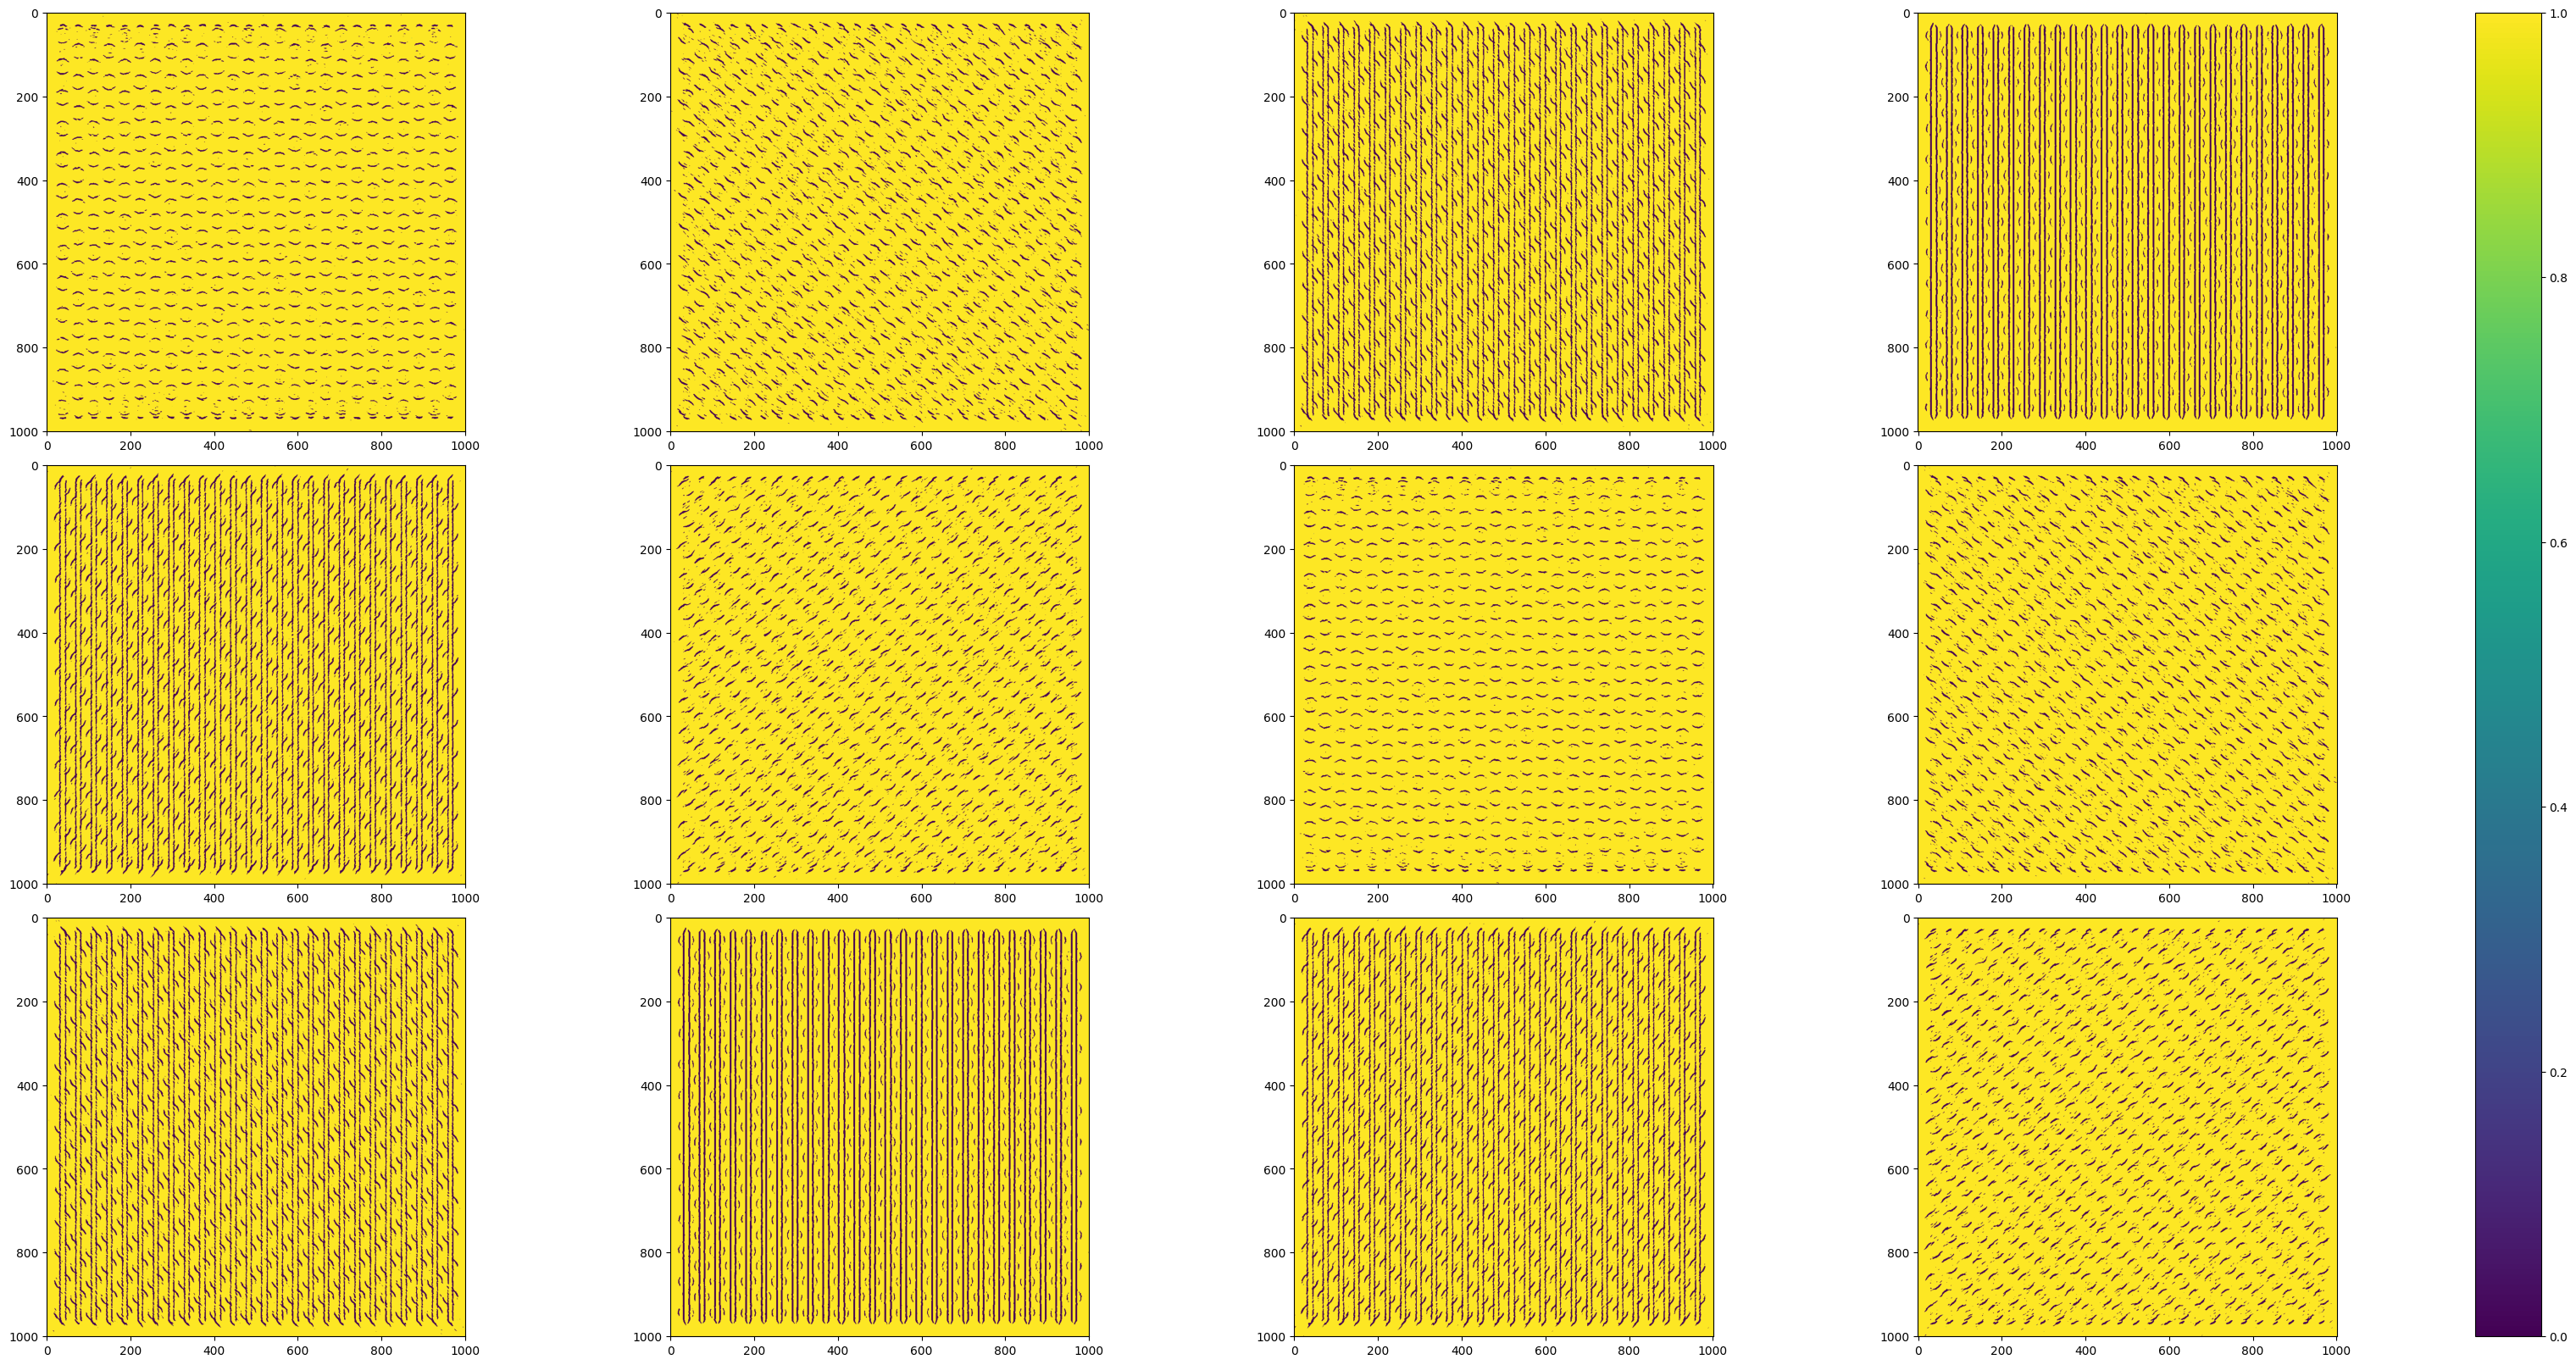

In [28]:
with torch.no_grad():
    output = model(fs[11][None],torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1 , torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]).cpu()

vmin = 0
vmax = 1

fig, ax = plt.subplots(ceil(output[0].shape[0]/4), 4, figsize=(8 * 4, 4 * 4), layout="constrained")

ims = []
for i in range(ceil(output[0].shape[0]/4)):
    for j in range(4):
        im = ax[i, j].imshow(output[0][i * 4 + j, :, :].cpu(), vmin=vmin, vmax=vmax,
                        cmap="viridis",
                        aspect="equal")
        ims.append(im)

fig.colorbar(ims[0], ax=ax, location="right");

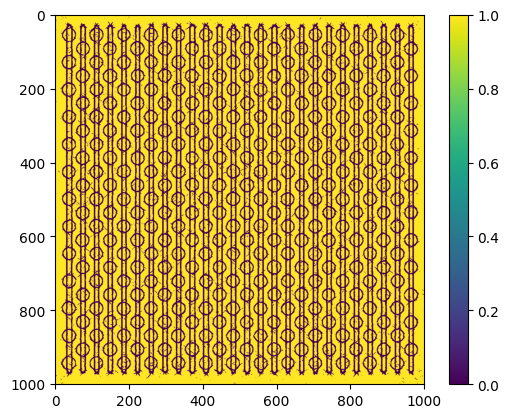

In [29]:
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(torch.min(output[0], dim=0)[0])
fig.colorbar(cbar, ax=ax)

In [30]:
with torch.no_grad():
    costfunctions= model(fs[-3:], torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1 , torch.sigmoid(t), torch.exp(log_scale)[None,:,None,None]).cpu()

#torch.save(costfunctions, "costfunctions.pt")

In [31]:
with torch.no_grad():
    costfunctions_nobin= model_nobin(fs[-3:], torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1, torch.exp(log_scale)[None,:,None,None]).cpu()

#torch.save(costfunctions_nobin, "costfunctions_nobin.pt")

#torch.save(costfunctions_nobin, f"costfunctions_shift_{shft}.pt")

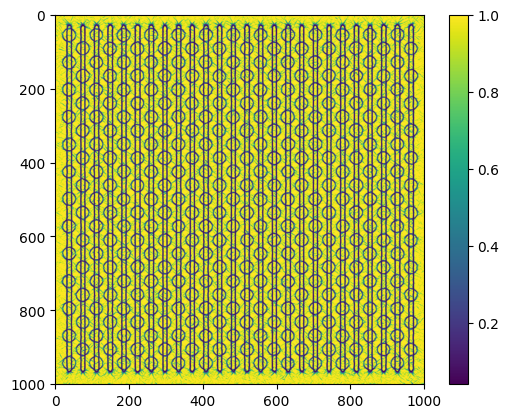

In [32]:
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(torch.min(costfunctions_nobin[0], dim=0)[0])
fig.colorbar(cbar, ax=ax)

test with images from EXPERIMENTAL data set

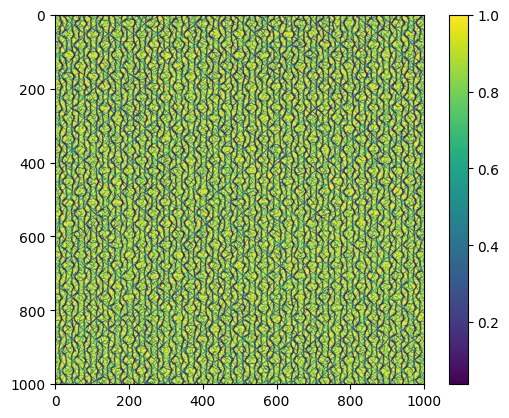

In [35]:
with torch.no_grad():
    costfunctions_test= model_nobin(test[:,200:1201,1000:2001], torch.exp(log_σs), torch.exp(log_σa), sqrt_λ_norm**2 * 100., torch.log(1 + torch.exp(sqrt_p)) + 1, torch.exp(log_scale)[None,:,None,None]).cpu()
    
fig, ax = plt.subplots(1, 1)
cbar = ax.imshow(torch.min(costfunctions_test[0], dim=0)[0])
fig.colorbar(cbar, ax=ax)


In [36]:
# torch.save(costfunctions_test, f"costfunctions_test_{index}.pt")